In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
# ============================================================
# CELL 1 — LME NICKEL CASH SETTLEMENT ($/t, monthly avg)
# Source: LME Official Website (manually transcribed)
# ============================================================

nickel_data = {
    '2019-04': 12819.00, '2019-05': 11998.33, '2019-06': 11970.00,
    '2019-07': 13462.39, '2019-08': 15682.14, '2019-09': 17673.10,
    '2019-10': 17113.48, '2019-11': 15199.52, '2019-12': 13800.50,
    '2020-01': 13552.95, '2020-02': 12743.50, '2020-03': 11873.00,
    '2020-04': 11753.20, '2020-05': 12135.32, '2020-06': 12703.27,
    '2020-07': 13341.35, '2020-08': 14486.85, '2020-09': 14866.27,
    '2020-10': 15219.36, '2020-11': 15796.05, '2020-12': 16807.05,
    '2021-01': 17847.60, '2021-02': 18568.05, '2021-03': 16459.87,
    '2021-04': 16480.70, '2021-05': 17605.74, '2021-06': 17943.23,
    '2021-07': 18817.05, '2021-08': 19160.43, '2021-09': 19398.41,
    '2021-10': 19420.24, '2021-11': 19964.32, '2021-12': 20070.24,
    '2022-01': 22326.00, '2022-02': 24178.00, '2022-03': 31860.65,
    '2022-04': 33298.42, '2022-05': 27950.00, '2022-06': 25837.50,
    '2022-07': 21483.33, '2022-08': 21997.73, '2022-09': 22682.27,
    '2022-10': 21935.71, '2022-11': 25257.05, '2022-12': 28853.75,
    '2023-01': 28240.48, '2023-02': 26689.75, '2023-03': 23307.17,
    '2023-04': 23756.67, '2023-05': 22229.50, '2023-06': 21192.95,
    '2023-07': 20898.33, '2023-08': 20497.73, '2023-09': 19629.05,
    '2023-10': 18255.23, '2023-11': 16979.77, '2023-12': 16388.68,
    '2024-01': 16091.36, '2024-02': 16307.62, '2024-03': 17432.75,
    '2024-04': 18173.81, '2024-05': 19520.00, '2024-06': 17508.25,
    '2024-07': 16396.30, '2024-08': 16249.76, '2024-09': 16117.86,
    '2024-10': 16804.57, '2024-11': 15740.24, '2024-12': 15470.50,
    '2025-01': 15378.64, '2025-02': 15274.75, '2025-03': 16054.52,
    '2025-04': 15209.50, '2025-05': 15324.75, '2025-06': 14989.29,
    '2025-07': 15023.26, '2025-08': 14909.00, '2025-09': 15102.05,
    '2025-10': 15079.78, '2025-11': 14689.25, '2025-12': 14878.81,
    '2026-01': 17844.05, '2026-02': 17132.75, '2026-03': 17093.18,
    '2026-04': 18005.75, '2026-05': 19128.00
}

ni_df = pd.Series(nickel_data)
ni_df.index = pd.to_datetime(ni_df.index)

In [3]:
# ============================================================
# CELL 2 — INDONESIAN PRODUCTION SHARE (%)
# Source: USGS Mineral Commodity Summaries 2020–2026
# ============================================================

indo_raw = {
    2019: 853000  / 2610000 * 100,   # 32.7%
    2020: 771000  / 2510000 * 100,   # 30.7%
    2021: 1000000 / 2700000 * 100,   # 37.0%
    2022: 1580000 / 3270000 * 100,   # 48.3%
    2023: 1800000 / 3600000 * 100,   # 50.0%
    2024: 2310000 / 3710000 * 100,   # 62.3%
    2025: 2600000 / 3900000 * 100,   # 66.7% (estimated)
}

indo_annual = pd.Series(indo_raw)
indo_annual.index = pd.to_datetime([f'{y}-07-01' for y in indo_raw.keys()])
indo_monthly = indo_annual.resample('MS').interpolate(method='linear')

print("Nickel data loaded:", len(ni_df), "months")
print("Indonesia share range:", round(indo_monthly.min(),1), "% to", round(indo_monthly.max(),1), "%")

Nickel data loaded: 86 months
Indonesia share range: 30.7 % to 66.7 %


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/graph1_nickel_2019_2026.png'

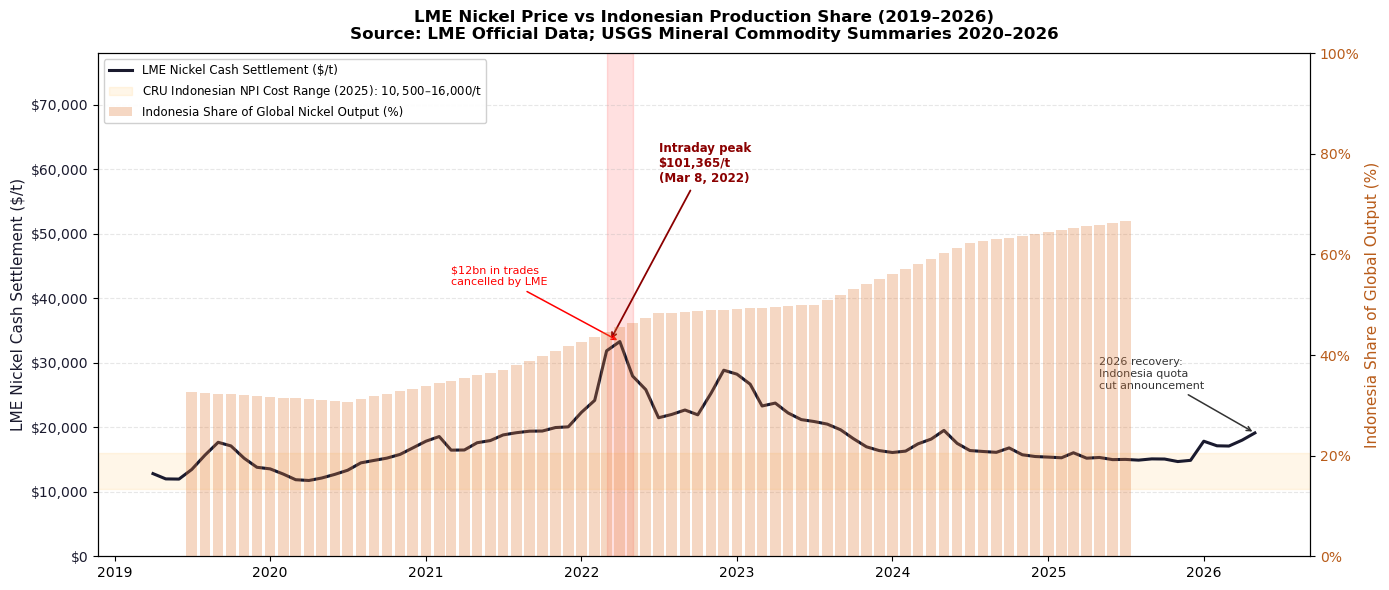

In [4]:
# ============================================================
# GRAPH 1: LME NICKEL + INDONESIAN PRODUCTION SHARE
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Nickel price
ax1.plot(ni_df.index, ni_df.values, color='#1a1a2e', linewidth=2.2,
         label='LME Nickel Cash Settlement ($/t)', zorder=3)

# Crisis shading
crisis_start = pd.Timestamp('2022-03-01')
crisis_end   = pd.Timestamp('2022-05-01')
ax1.axvspan(crisis_start, crisis_end, alpha=0.12, color='red', zorder=1)

# NPI cost floor band
ax1.axhspan(10500, 16000, alpha=0.09, color='orange',
            label='CRU Indonesian NPI Cost Range (2025): $10,500–$16,000/t')

# Indonesian share bars
ax2.bar(indo_monthly.index, indo_monthly.values, width=25,
        alpha=0.30, color='#e07b39',
        label='Indonesia Share of Global Nickel Output (%)')

# Annotations
ax1.annotate(
    'Intraday peak\n$101,365/t\n(Mar 8, 2022)',
    xy=(pd.Timestamp('2022-03-08'), 33298),
    xytext=(pd.Timestamp('2022-07-01'), 58000),
    fontsize=8.5, color='darkred', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkred', lw=1.3)
)

ax1.annotate(
    '$12bn in trades\ncancelled by LME',
    xy=(pd.Timestamp('2022-04-01'), 33298),
    xytext=(pd.Timestamp('2021-03-01'), 42000),
    fontsize=8, color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.1)
)

ax1.annotate(
    '2026 recovery:\nIndonesia quota\ncut announcement',
    xy=(pd.Timestamp('2026-05-01'), 19128),
    xytext=(pd.Timestamp('2025-05-01'), 26000),
    fontsize=8, color='#333333',
    arrowprops=dict(arrowstyle='->', color='#333333', lw=1.1)
)

# Axis labels
ax1.set_ylabel('LME Nickel Cash Settlement ($/t)', fontsize=11, color='#1a1a2e')
ax2.set_ylabel('Indonesia Share of Global Output (%)', fontsize=11, color='#b85c1a')
ax1.tick_params(axis='y', labelcolor='#1a1a2e')
ax2.tick_params(axis='y', labelcolor='#b85c1a')
ax1.set_ylim(0, 78000)
ax2.set_ylim(0, 100)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ax1.set_title(
    'LME Nickel Price vs Indonesian Production Share (2019–2026)\n'
    'Source: LME Official Data; USGS Mineral Commodity Summaries 2020–2026',
    fontsize=12, fontweight='bold', pad=10
)
ax1.set_xlabel('')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=8.5, framealpha=0.92)

ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/graph1_nickel_2019_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph 1 saved.")

In [5]:
# ============================================================
# CELL 3 — LME ALUMINIUM CASH SETTLEMENT ($/t, monthly avg)
# Source: LME Official Website (manually transcribed)
# ============================================================

aluminium_data = {
    '2019-04': 1848.98, '2019-05': 1775.33, '2019-06': 1754.08,
    '2019-07': 1792.83, '2019-08': 1740.93, '2019-09': 1749.60,
    '2019-10': 1718.83, '2019-11': 1772.31, '2019-12': 1770.40,
    '2020-01': 1771.73, '2020-02': 1685.85, '2020-03': 1611.14,
    '2020-04': 1457.15, '2020-05': 1459.79, '2020-06': 1564.02,
    '2020-07': 1639.35, '2020-08': 1733.90, '2020-09': 1745.34,
    '2020-10': 1802.82, '2020-11': 1932.12, '2020-12': 2017.90,
    '2021-01': 2003.80, '2021-02': 2079.60, '2021-03': 2191.59,
    '2021-04': 2323.75, '2021-05': 2433.84, '2021-06': 2439.09,
    '2021-07': 2491.95, '2021-08': 2610.64, '2021-09': 2839.68,
    '2021-10': 2955.17, '2021-11': 2641.41, '2021-12': 2695.36,
    '2022-01': 3003.08, '2022-02': 3260.83, '2022-03': 3537.85,
    '2022-04': 3256.58, '2022-05': 2826.36, '2022-06': 2562.93,
    '2022-07': 2401.57, '2022-08': 2431.32, '2022-09': 2229.91,
    '2022-10': 2243.29, '2022-11': 2335.27, '2022-12': 2394.88,
    '2023-01': 2489.02, '2023-02': 2417.28, '2023-03': 2290.11,
    '2023-04': 2341.00, '2023-05': 2267.60, '2023-06': 2181.07,
    '2023-07': 2152.38, '2023-08': 2134.16, '2023-09': 2177.50,
    '2023-10': 2192.45, '2023-11': 2202.23, '2023-12': 2174.29,
    '2024-01': 2194.18, '2024-02': 2182.55, '2024-03': 2222.35,
    '2024-04': 2497.88, '2024-05': 2565.19, '2024-06': 2495.05,
    '2024-07': 2362.30, '2024-08': 2334.33, '2024-09': 2451.67,
    '2024-10': 2598.39, '2024-11': 2583.19, '2024-12': 2538.43,
    '2025-01': 2574.95, '2025-02': 2653.38, '2025-03': 2657.21,
    '2025-04': 2381.25, '2025-05': 2442.40, '2025-06': 2516.48,
    '2025-07': 2604.15, '2025-08': 2594.03, '2025-09': 2653.25,
    '2025-10': 2786.30, '2025-11': 2822.93, '2025-12': 2875.45,
    '2026-01': 3148.40, '2026-02': 3065.35, '2026-03': 3370.16,
    '2026-04': 3600.63, '2026-05': 3586.60
}

al_df = pd.Series(aluminium_data)
al_df.index = pd.to_datetime(al_df.index)

In [6]:
# ============================================================
# CELL 4 — MIDWEST PREMIUM ($/t, monthly)
# Source: Investing.com — Aluminium Premium Duty Paid US Midwest
# ============================================================

mw_data = {
    '2019-04': 417.78, '2019-05': 420.05, '2019-06': 413.44,
    '2019-07': 394.25, '2019-08': 387.42, '2019-09': 392.49,
    '2019-10': 390.29, '2019-11': 343.54, '2019-12': 319.13,
    '2020-01': 309.80, '2020-02': 300.43, '2020-03': 290.62,
    '2020-04': 215.76, '2020-05': 178.83, '2020-06': 189.00,
    '2020-07': 220.50, '2020-08': 318.62, '2020-09': 312.01,
    '2020-10': 266.81, '2020-11': 286.65, '2020-12': 312.67,
    '2021-01': 329.65, '2021-02': 342.66, '2021-03': 415.64,
    '2021-04': 517.07, '2021-05': 584.33, '2021-06': 607.43,
    '2021-07': 675.39, '2021-08': 760.06, '2021-09': 764.95,
    '2021-10': 763.95, '2021-11': 608.93, '2021-12': 604.91,
    '2022-01': 717.44, '2022-02': 798.29, '2022-03': 865.74,
    '2022-04': 877.90, '2022-05': 819.38, '2022-06': 717.71,
    '2022-07': 632.67, '2022-08': 581.57, '2022-09': 532.77,
    '2022-10': 452.73, '2022-11': 435.71, '2022-12': 447.65,
    '2023-01': 602.65, '2023-02': 646.28, '2023-03': 601.74,
    '2023-04': 556.05, '2023-05': 549.61, '2023-06': 525.80,
    '2023-07': 525.80, '2023-08': 473.99, '2023-09': 473.99,
    '2023-10': 455.91, '2023-11': 412.68, '2023-12': 445.83,
    '2024-01': 446.44, '2024-02': 417.22, '2024-03': 421.63,
    '2024-04': 428.33, '2024-05': 460.77, '2024-06': 451.34,
    '2024-07': 421.63, '2024-08': 421.63, '2024-09': 435.41,
    '2024-10': 435.41, '2024-11': 468.98, '2024-12': 518.98,
    '2025-01': 593.98, '2025-02': 714.48, '2025-03': 827.23,
    '2025-04': 868.00, '2025-05': 838.00, '2025-06': 1256.41,
    '2025-07': 1557.56, '2025-08': 1339.31, '2025-09': 1616.93,
    '2025-10': 1793.99
}

mw_df = pd.Series(mw_data)
mw_df.index = pd.to_datetime(mw_df.index)

# All-in price = LME + MW Premium (aligned dates)
common_idx = al_df.index.intersection(mw_df.index)
allin_df = al_df[common_idx] + mw_df[common_idx]

print("Aluminium data loaded:", len(al_df), "months")
print("MW Premium peak:", round(mw_df.max(), 2), "$/t in", mw_df.idxmax().strftime('%b %Y'))
print("All-in price peak:", round(allin_df.max(), 2), "$/t in", allin_df.idxmax().strftime('%b %Y'))

Aluminium data loaded: 86 months
MW Premium peak: 1793.99 $/t in Oct 2025
All-in price peak: 4580.29 $/t in Oct 2025


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/graph2_aluminium_2019_2025.png'

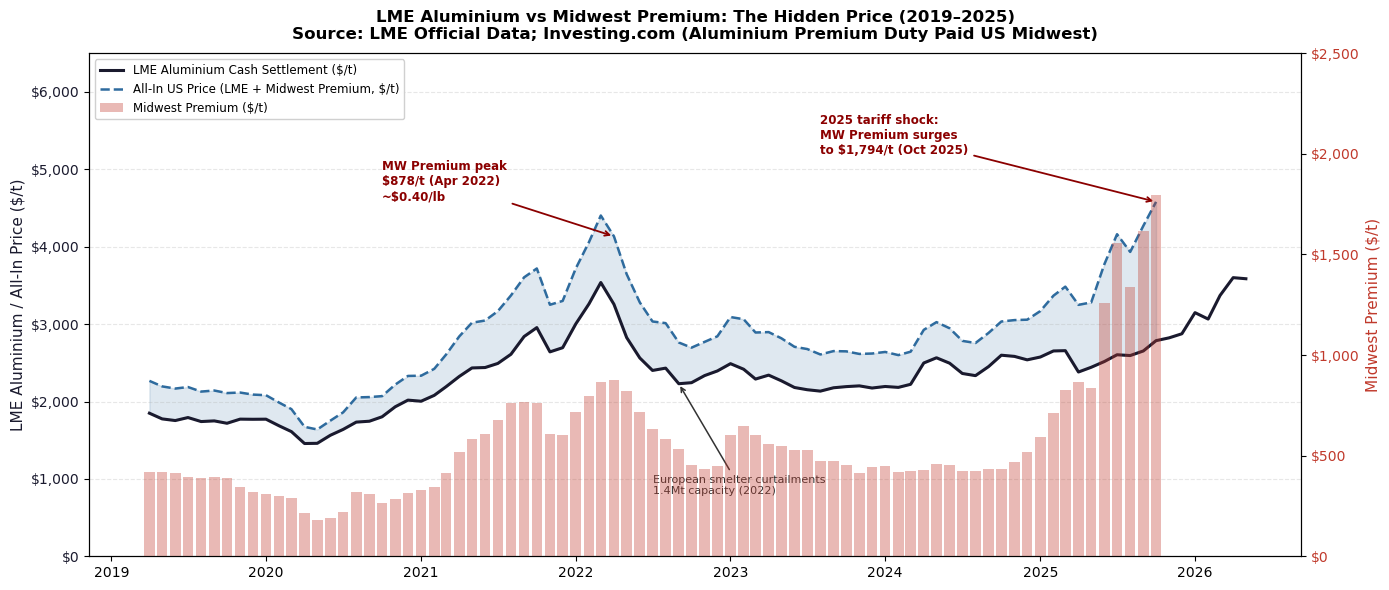

In [7]:
# ============================================================
# GRAPH 2: LME ALUMINIUM + MIDWEST PREMIUM
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# LME price
ax1.plot(al_df.index, al_df.values, color='#1a1a2e', linewidth=2.2,
         label='LME Aluminium Cash Settlement ($/t)', zorder=3)

# All-in price
ax1.plot(allin_df.index, allin_df.values, color='#2e6b9e', linewidth=1.8,
         linestyle='--', label='All-In US Price (LME + Midwest Premium, $/t)', zorder=3)

# Fill between LME and all-in
ax1.fill_between(common_idx, al_df[common_idx], allin_df,
                 alpha=0.15, color='#2e6b9e', label='_nolegend_')

# MW Premium bars
ax2.bar(mw_df.index, mw_df.values, width=25, alpha=0.35,
        color='#c0392b', label='Midwest Premium ($/t)')

# Key annotations
ax1.annotate(
    'MW Premium peak\n$878/t (Apr 2022)\n~$0.40/lb',
    xy=(pd.Timestamp('2022-04-01'), 877.90 + 3256.58),
    xytext=(pd.Timestamp('2020-10-01'), 4600),
    fontsize=8.5, color='darkred', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkred', lw=1.3)
)

ax1.annotate(
    '2025 tariff shock:\nMW Premium surges\nto $1,794/t (Oct 2025)',
    xy=(pd.Timestamp('2025-10-01'), 1793.99 + 2786.30),
    xytext=(pd.Timestamp('2023-08-01'), 5200),
    fontsize=8.5, color='darkred', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkred', lw=1.3)
)

ax1.annotate(
    'European smelter curtailments\n1.4Mt capacity (2022)',
    xy=(pd.Timestamp('2022-09-01'), 2229.91),
    xytext=(pd.Timestamp('2022-07-01'), 800),
    fontsize=8, color='#333333',
    arrowprops=dict(arrowstyle='->', color='#333333', lw=1.1)
)

# Labels
ax1.set_ylabel('LME Aluminium / All-In Price ($/t)', fontsize=11, color='#1a1a2e')
ax2.set_ylabel('Midwest Premium ($/t)', fontsize=11, color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#1a1a2e')
ax2.tick_params(axis='y', labelcolor='#c0392b')

ax1.set_ylim(0, 6500)
ax2.set_ylim(0, 2500)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax1.set_title(
    'LME Aluminium vs Midwest Premium: The Hidden Price (2019–2025)\n'
    'Source: LME Official Data; Investing.com (Aluminium Premium Duty Paid US Midwest)',
    fontsize=12, fontweight='bold', pad=10
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=8.5, framealpha=0.92)

ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/graph2_aluminium_2019_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph 2 saved.")

In [9]:
import numpy as np, os, warnings
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from numpy.linalg import lstsq
warnings.filterwarnings("ignore")

In [10]:
# ─── Data ───────────────────────────────────────────────────────────────────
ni_pre  = np.array([12819,11998.33,11970,13462.39,15682.14,17673.10,17113.48,15199.52,
 13800.50,13552.95,12743.50,11873,11753.20,12135.32,12703.27,13341.35,14486.85,
 14866.27,15219.36,15796.05,16807.05,17847.60,18568.05,16459.87,16480.70,17605.74,
 17943.23,18817.05,19160.43,19398.41,19420.24,19964.32,20070.24,22326,24178])

ni_post = np.array([33298.42,27950,25837.50,21483.33,21997.73,22682.27,21935.71,25257.05,
 28853.75,28240.48,26689.75,23307.17,23756.67,22229.50,21192.95,20898.33,20497.73,
 19629.05,18255.23,16979.77,16388.68,16091.36,16307.62,17432.75,18173.81,19520,
 17508.25,16396.30,16249.76,16117.86,16804.57,15740.24,15470.50,15378.64,15274.75,
 16054.52,15209.50,15324.75,14989.29,15023.26,14909,15102.05,15079.78,14689.25,
 14878.81,17844.05,17132.75,17093.18,18005.75,19128])

al_arr = np.array([1848.98,1775.33,1754.08,1792.83,1740.93,1749.60,1718.83,1772.31,1770.40,
 1771.73,1685.85,1611.14,1457.15,1459.79,1564.02,1639.35,1733.90,1745.34,1802.82,
 1932.12,2017.90,2003.80,2079.60,2191.59,2323.75,2433.84,2439.09,2491.95,2610.64,
 2839.68,2955.17,2641.41,2695.36,3003.08,3260.83,3537.85,3256.58,2826.36,2562.93,
 2401.57,2431.32,2229.91,2243.29,2335.27,2394.88,2489.02,2417.28,2290.11,2341.00,
 2267.60,2181.07,2152.38,2134.16,2177.50,2192.45,2202.23,2174.29,2194.18,2182.55,
 2222.35,2497.88,2565.19,2495.05,2362.30,2334.33,2451.67,2598.39,2583.19,2538.43,
 2574.95,2653.38,2657.21,2381.25,2442.40,2516.48,2604.15,2594.03,2653.25,2786.30])

mw_arr = np.array([417.78,420.05,413.44,394.25,387.42,392.49,390.29,343.54,319.13,309.80,
 300.43,290.62,215.76,178.83,189.00,220.50,318.62,312.01,266.81,286.65,312.67,329.65,
 342.66,415.64,517.07,584.33,607.43,675.39,760.06,764.95,763.95,608.93,604.91,717.44,
 798.29,865.74,877.90,819.38,717.71,632.67,581.57,532.77,452.73,435.71,447.65,602.65,
 646.28,601.74,556.05,549.61,525.80,525.80,473.99,473.99,455.91,412.68,445.83,446.44,
 417.22,421.63,428.33,460.77,451.34,421.63,421.63,435.41,435.41,468.98,518.98,593.98,
 714.48,827.23,868.00,838.00,1256.41,1557.56,1339.31,1616.93,1793.99])

allin_arr = al_arr + mw_arr

In [11]:
# ─── OU Estimation ──────────────────────────────────────────────────────────
def fit_ou(series, label, dt=1/12):
    x = series[:-1]; y = series[1:]
    A = np.column_stack([np.ones(len(x)), x])
    (alpha, beta), _, _, _ = lstsq(A, y, rcond=None)
    resid = y - (alpha + beta * x)
    se    = float(np.std(resid))
    beta  = float(np.clip(beta, 1e-4, 1 - 1e-4))
    kappa = -np.log(beta) / dt
    mu    = alpha / (1 - beta)
    r2    = 1 - np.var(resid) / np.var(y)
    hl    = np.log(2) / kappa if kappa > 0.01 else np.inf
    flag  = " ← near-random-walk / trending" if kappa < 0.05 else ""
    print(f"\n{'='*54}\n  {label}\n{'='*54}")
    print(f"  kappa : {kappa:.4f}/month  |  half-life: {hl:.1f} months{flag}")
    print(f"  mu    : ${float(mu):,.0f}/t" + (" (unreliable — kappa≈0)" if kappa < 0.05 else ""))
    print(f"  sigma : ${se:,.0f}/t (monthly residual std)  |  R²: {r2:.4f}")
    return float(kappa), float(mu), se

k_pre,  mu_pre,  se_pre  = fit_ou(ni_pre,  "NICKEL Pre-Crisis  (Apr 2019 – Feb 2022)")
k_post, mu_post, se_post = fit_ou(ni_post, "NICKEL Post-Crisis (Apr 2022 – May 2026)")
k_lme,  mu_lme,  se_lme  = fit_ou(al_arr,  "ALUMINIUM LME Only")
k_all,  mu_all,  se_all  = fit_ou(allin_arr,"ALUMINIUM All-In  (LME + MW Premium)")

# For MC, cap kappa at sensible lower bound to avoid divergence
k_lme_mc = max(k_lme, 0.10); k_all_mc = max(k_all, 0.05)
mu_all_mc = float(np.mean(allin_arr))   # use empirical mean for non-stationary series


  NICKEL Pre-Crisis  (Apr 2019 – Feb 2022)
  kappa : 0.0012/month  |  half-life: inf months ← near-random-walk / trending
  mu    : $-2,330,542/t (unreliable — kappa≈0)
  sigma : $1,030/t (monthly residual std)  |  R²: 0.8919

  NICKEL Post-Crisis (Apr 2022 – May 2026)
  kappa : 2.1540/month  |  half-life: 0.3 months
  mu    : $17,447/t
  sigma : $1,380/t (monthly residual std)  |  R²: 0.8802

  ALUMINIUM LME Only
  kappa : 0.5378/month  |  half-life: 1.3 months
  mu    : $2,552/t
  sigma : $127/t (monthly residual std)  |  R²: 0.9101

  ALUMINIUM All-In  (LME + MW Premium)
  kappa : 0.0012/month  |  half-life: inf months ← near-random-walk / trending
  mu    : $271,285/t (unreliable — kappa≈0)
  sigma : $184/t (monthly residual std)  |  R²: 0.9229


In [12]:
# ─── Monte Carlo ─────────────────────────────────────────────────────────────
def mc(kappa, mu, se, S0, n_steps=252, n_sims=5000, seed=42):
    np.random.seed(seed)
    sd = se / np.sqrt(21); k = kappa / 21
    P  = np.zeros((n_sims, n_steps)); P[:,0] = S0
    for t in range(1, n_steps):
        P[:,t] = np.clip(P[:,t-1] + k*(mu - P[:,t-1]) + sd*np.random.normal(0,1,n_sims),
                         100, None)
    return P

pl = mc(k_lme_mc, mu_lme,   se_lme, al_arr[-1])
pa = mc(k_all_mc, mu_all_mc, se_all, allin_arr[-1])
tl = pl[:,-1]; ta = pa[:,-1]
p50l,p90l = np.percentile(tl,[50,90]); p50a,p90a = np.percentile(ta,[50,90])
gap = p90a - p90l

print(f"\n{'='*54}\n  MONTE CARLO (5,000 paths | 252-day horizon)\n{'='*54}")
print(f"  LME-only  p50: ${p50l:,.0f}/t   p90: ${p90l:,.0f}/t")
print(f"  All-In    p50: ${p50a:,.0f}/t   p90: ${p90a:,.0f}/t")
print(f"  90th pct gap : ${gap:,.0f}/t   Tail exposure (50kt/yr): ${gap*50000/1e6:.1f}m")


  MONTE CARLO (5,000 paths | 252-day horizon)
  LME-only  p50: $2,551/t   p90: $2,706/t
  All-In    p50: $3,794/t   p90: $4,404/t
  90th pct gap : $1,698/t   Tail exposure (50kt/yr): $84.9m


In [13]:
# ─── Plot ────────────────────────────────────────────────────────────────────
os.makedirs("outputs", exist_ok=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: regime comparison bar chart
regime_labels = ["Pre-Crisis\n(trending)", "Post-Crisis\n(mean-reverting)"]
regime_mu     = [float(np.mean(ni_pre)), mu_post]   # use empirical mean for pre
colors        = ["#1a1a2e", "#c0392b"]
bars = ax1.bar(regime_labels, regime_mu, color=colors, width=0.4, edgecolor="white")
ax1.axhspan(10500, 16000, alpha=0.12, color="orange")
ax1.axhline(10500, color="orange",    linestyle="--", linewidth=1.4,
            label="CRU NPI cost floor: $10,500/t")
ax1.axhline(16000, color="darkorange", linestyle=":",  linewidth=1.4,
            label="CRU NPI cost ceiling: $16,000/t")
for b, m in zip(bars, regime_mu):
    ax1.text(b.get_x()+b.get_width()/2, m*1.02, f"${m:,.0f}/t",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_ylim(0, max(regime_mu)*1.45)
ax1.set_ylabel("Price Level ($/t)", fontsize=10)
ax1.set_title("LME Nickel: Regime Mean\nPre vs Post March 2022", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8, loc="upper right")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Right: terminal distributions
lo = min(np.percentile(tl,1), np.percentile(ta,1))
hi = max(np.percentile(tl,99), np.percentile(ta,99))
bins = np.linspace(lo, hi, 60)
ax2.hist(tl, bins=bins, alpha=0.55, color="#1a1a2e", label="LME-Only",   density=True)
ax2.hist(ta, bins=bins, alpha=0.55, color="#c0392b", label="All-In (LME+MW)", density=True)
ax2.axvline(p90l, color="#1a1a2e", linestyle="--", linewidth=2,
            label=f"LME p90: ${p90l:,.0f}/t")
ax2.axvline(p90a, color="#c0392b", linestyle="--", linewidth=2,
            label=f"All-In p90: ${p90a:,.0f}/t")
ylim = ax2.get_ylim()[1]
ax2.fill_betweenx([0, max(ylim, 1e-6)], p90l, p90a, alpha=0.15, color="red",
                  label=f"Gap: ${gap:,.0f}/t")
ax2.set_xlabel("12-Month Terminal Price ($/t)", fontsize=10)
ax2.set_ylabel("Density", fontsize=10)
ax2.set_title(f"Aluminium Procurement Distributions\n"
              f"5,000 MC paths | Tail exposure (50kt/yr): ${gap*50000/1e6:.1f}m",
              fontsize=10, fontweight="bold")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle("Stochastic Modelling: Nickel Regime Break & Aluminium Procurement Risk",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("outputs/ou_model_results.png", dpi=120, bbox_inches="tight")
print("\nSaved: outputs/ou_model_results.png")


Saved: outputs/ou_model_results.png
